
# RSGM Inference Visualizer

Step-by-step interactive visualization of the reverse diffusion on S².

**Requirements:** `pip install ipympl` for interactive 3D rotation (`%matplotlib widget`).

In [1]:
import os
import sys

os.environ["GEOMSTATS_BACKEND"] = "jax"

# Repo root
REPO_ROOT = os.path.abspath(os.getcwd())

# Add vendored geomstats package
GEOMSTATS_ROOT = os.path.join(REPO_ROOT, "geomstats")

if GEOMSTATS_ROOT not in sys.path:
    sys.path.insert(0, GEOMSTATS_ROOT)

if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

print("geomstats path:", GEOMSTATS_ROOT)
print("sys.path[0:3]:", sys.path[:3])

from functools import partial

import numpy as np
import jax
import jax.numpy as jnp
import haiku as hk
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

from omegaconf import OmegaConf
from hydra.utils import instantiate, get_class

from score_sde.utils import restore
from score_sde.models.flow import (
    make_safe_score_fn_spectral,
    make_safe_score_fn_varadhan,
    make_safe_score_fn_barrier,
    make_safe_score_fn_experimental,
    clear_score_log,
    get_score_log,
)
from score_sde.sampling import get_pc_sampler


print("JAX devices:", jax.devices())

RUN_DIR = os.path.join(
    REPO_ROOT,
    "results/ring_synthetic/dataset.concentration=100,dataset.n_samples=10000,steps=100000/0",
)

assert os.path.isdir(RUN_DIR), f"Run directory not found: {RUN_DIR}"
print("Using run:", RUN_DIR)

PLOTS_DIR = "plots"
os.makedirs(PLOTS_DIR, exist_ok=True)
print("Plots directory:", PLOTS_DIR)

# Register resolvers so OmegaConf can interpolate Hydra-specific variables
try:
    OmegaConf.register_new_resolver("hydra", lambda key: RUN_DIR, replace=True)
except Exception:
    pass  # already registered
try:
    OmegaConf.register_new_resolver("now", lambda fmt: "notebook", replace=True)
except Exception:
    pass

cfg = OmegaConf.load(os.path.join(RUN_DIR, ".hydra", "config.yaml"))

# Override work_dir so ${work_dir}/... interpolations resolve to the run directory
OmegaConf.update(cfg, "work_dir", RUN_DIR, merge=False)

print(OmegaConf.to_yaml(cfg.manifold))

geomstats path: /Users/michalisdikaiopoulos/Desktop/Master/Thesis/riemannian-score-sde/geomstats
sys.path[0:3]: ['/Users/michalisdikaiopoulos/Desktop/Master/Thesis/riemannian-score-sde/geomstats', '/Users/michalisdikaiopoulos/Desktop/Master/Thesis/riemannian-score-sde', '/Applications/PyCharm.app/Contents/plugins/python-ce/helpers/pydev']
JAX devices: [CpuDevice(id=0)]
Using run: /Users/michalisdikaiopoulos/Desktop/Master/Thesis/riemannian-score-sde/results/ring_synthetic/dataset.concentration=100,dataset.n_samples=10000,steps=100000/0
Plots directory: plots
_target_: geomstats.geometry.hypersphere.Hypersphere
dim: 2



## 3 — Reconstruct the model and pushforward

In [2]:
rng = jax.random.PRNGKey(cfg.seed)

data_manifold  = instantiate(cfg.manifold)
transform      = instantiate(cfg.transform, data_manifold)
model_manifold = transform.domain
beta_schedule  = instantiate(cfg.beta_schedule)
flow           = instantiate(cfg.flow, manifold=model_manifold, beta_schedule=beta_schedule)
base           = instantiate(cfg.base, model_manifold, flow)
pushforward    = instantiate(cfg.pushf, flow, base, transform=transform)

# Build the score network (mirrors run.py)
def _model(y, t, context=None):
    output_shape = get_class(cfg.generator._target_).output_shape(model_manifold)
    score = instantiate(
        cfg.generator,
        cfg.architecture,
        cfg.embedding,
        output_shape,
        manifold=model_manifold,
    )
    context = t if context is None else jnp.concatenate(
        [jnp.expand_dims(t.reshape(-1), -1), context], axis=-1
    )
    return score(y, context)

model = hk.transform_with_state(_model)

# Initialise with a dummy batch to build the parameter tree
rng, init_rng = jax.random.split(rng)
y_dummy = jnp.array(data_manifold.random_uniform(state=init_rng, n_samples=4))
t_dummy = jnp.zeros((4, 1))
params, state = model.init(rng=init_rng, y=transform.inv(y_dummy), t=t_dummy, context=None)

print("Model initialised — parameter count:",
      sum(x.size for x in jax.tree_util.tree_leaves(params)))

INFO: Using jax backend


Model initialised — parameter count: 1054723


## 4 — Restore checkpoint

In [3]:
ckpt_path   = os.path.join(RUN_DIR, cfg.ckpt_dir)
train_state = restore(ckpt_path)

print(f"Restored checkpoint at step {train_state.step}")

Restored checkpoint at step 90001


## 5 — Safety configuration (optional)

Set `USE_SAFETY = True` and choose a method to activate a safety mechanism during sampling.

In [4]:
USE_SAFETY = True          # flip to True to enable
SAFETY_METHOD = "experimental"  # "spectral" | "varadhan" | "barrier" | "experimental"

# Unsafe region: azimuthal wedge phi in [phi_min, phi_max]
PHI_MIN = cfg.safety.phi_min   # default -0.3
PHI_MAX = cfg.safety.phi_max   # default  0.3

latitude = float(cfg.dataset.get("latitude", 0.0))
concentration = float(cfg.dataset.get("concentration", 20.0))

_theta_center = np.pi / 2 - latitude
_band_half = 3.0 / np.sqrt(concentration)

# Collect unsafe reference points from real data — mirrors run.py logic
if USE_SAFETY:
    _full_dataset = instantiate(cfg.dataset, rng=jax.random.PRNGKey(cfg.seed))
    all_data = _full_dataset.data                             # [n_samples, 3]
    phi_all  = jnp.arctan2(all_data[:, 1], all_data[:, 0])
    mask     = (phi_all > PHI_MIN) & (phi_all < PHI_MAX)
    unsafe_points = all_data[mask][:cfg.safety.target_n]

    print(f"Collected {unsafe_points.shape[0]} unsafe reference points from real data")
else:
    unsafe_points = None

safety_cfg = cfg.safety if USE_SAFETY else None
if USE_SAFETY:
    safety_cfg = OmegaConf.merge(safety_cfg, {"method": SAFETY_METHOD})

print("Safety:", "ON —", SAFETY_METHOD if USE_SAFETY else "OFF")

Collected 30 unsafe reference points from real data
Safety: ON — experimental


## 6 — Run reverse diffusion and collect full trajectory

The trajectory `x_hist` has shape `[N_steps, n_samples, 3]`.

In [5]:
N_STEPS   = 100   # diffusion steps
N_SAMPLES = 10    # number of particles to track
EPS       = getattr(cfg, "eps", 1e-3)

rng, sample_rng = jax.random.split(rng)

# Initial noise
z = pushforward.base.sample(sample_rng, (N_SAMPLES,))

# Build score function
model_w_dicts = (model, train_state.params_ema, train_state.model_state)
score_fn = pushforward.sde.reparametrise_score_fn(*model_w_dicts)
score_fn = partial(score_fn, context=None)

# Save the plain (learned) score before any safety wrapping
score_fn_plain = score_fn

# Optionally wrap with a safety correction
if safety_cfg is not None and unsafe_points is not None:
    if SAFETY_METHOD == "spectral":
        score_fn = make_safe_score_fn_spectral(
            score_fn, unsafe_points, pushforward.transform.domain,
            eta=safety_cfg.eta, beta_max=safety_cfg.beta_max,
            t_min=safety_cfg.t_min, n_max=safety_cfg.n_max,
        )
    elif SAFETY_METHOD == "varadhan":
        score_fn = make_safe_score_fn_varadhan(
            score_fn, unsafe_points, pushforward.transform.domain,
            eta=safety_cfg.eta, beta_max=safety_cfg.beta_max,
        )
    elif SAFETY_METHOD == "barrier":
        score_fn = make_safe_score_fn_barrier(
            score_fn,
            phi_min=safety_cfg.phi_min, phi_max=safety_cfg.phi_max,
            eta=safety_cfg.eta, t_barrier=safety_cfg.t_barrier,
        )

    elif SAFETY_METHOD == "experimental":
        score_fn = make_safe_score_fn_experimental(
            score_fn,
            unsafe_points,
            pushforward.transform.domain,
            eta=safety_cfg.eta,
            beta_max=safety_cfg.beta_max,
            t_min=safety_cfg.t_min,
            t_max=float(safety_cfg.get("t_max", 0.4)),
        )

# Reverse SDE + PC sampler with full history
reverse_sde = pushforward.sde.reverse(score_fn)
sampler = get_pc_sampler(
    reverse_sde,
    unsafe_points=None,   # score correction already applied above
    safety_cfg=None,
    N=N_STEPS,
    predictor="GRW",
    eps=EPS,
    return_hist=True,
)
clear_score_log()
sampler = jax.jit(sampler)

print("JIT-compiling sampler … (first call is slow)")
x_final, x_hist, timesteps = sampler(sample_rng, z)

# Map from model manifold to data manifold
x_hist = np.array(jax.vmap(pushforward.transform)(x_hist))   # [N_steps, n_samples, 3]
timesteps = np.array(timesteps)                               # [N_steps] or [N_steps, n_samples]

print(f"Trajectory shape: {x_hist.shape}  |  t range: {timesteps.min():.3f} → {timesteps.max():.3f}")

---- Experimental safety method used! ----
JIT-compiling sampler … (first call is slow)
Trajectory shape: (100, 10, 3)  |  t range: 0.001 → 1.000


In [6]:
import pandas as pd

log = get_score_log()
if log:
    df_log = pd.DataFrame(log)
    df_log.index += 1
    df_log.index.name = 'call'
    display(df_log)
else:
    print('No log entries — spectral method may not have been active.')


,t,|learned|,|unsafe|,|correction|,|safe|
call,,,,,
1,1.000000,0.003515,0.003515,0.003515,0.003515
2,0.989909,0.003122,0.003122,0.003122,0.003122
3,0.979818,0.003726,0.003726,0.003726,0.003726
4,0.969727,0.003912,0.003912,0.003912,0.003912
5,0.959636,0.005126,0.005126,0.005126,0.005126
...,...,...,...,...,...
96,0.041364,3.759629,3.759629,3.759629,5.255137
97,0.031273,4.566745,4.566745,4.566745,6.001634
98,0.021182,5.177679,5.177679,5.177679,6.448452


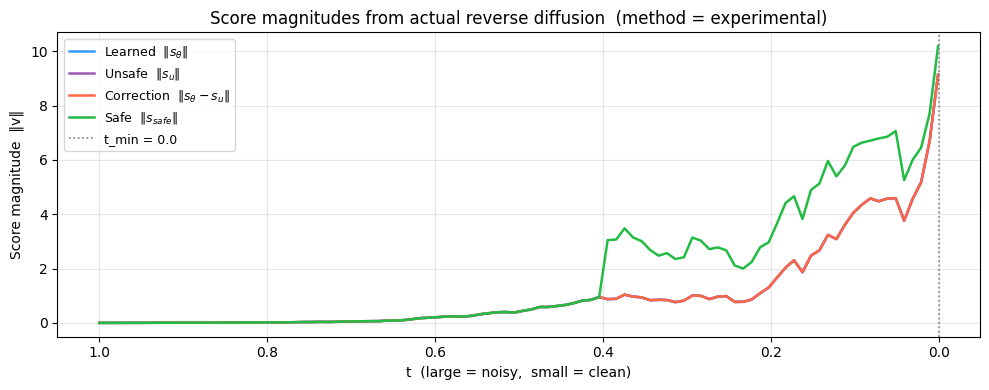

In [7]:
%matplotlib inline

if log:
    fig, ax = plt.subplots(figsize=(10, 4))

    ax.plot(df_log['t'], df_log['|learned|'],    color='#3399ff', linewidth=1.8, label='Learned  $\\|s_\\theta\\|$')
    ax.plot(df_log['t'], df_log['|unsafe|'],     color='#9b59b6', linewidth=1.8, label='Unsafe  $\\|s_u\\|$')
    ax.plot(df_log['t'], df_log['|correction|'], color='#ff6644', linewidth=1.8, label='Correction  $\\|s_\\theta - s_u\\|$')
    ax.plot(df_log['t'], df_log['|safe|'],        color='#22bb44', linewidth=1.8, label='Safe  $\\|s_{safe}\\|$')

    if USE_SAFETY and hasattr(safety_cfg, 't_min'):
        ax.axvline(float(safety_cfg.t_min), color='gray', linestyle=':', linewidth=1.2,
                   label=f't_min = {float(safety_cfg.t_min)}')

    ax.set_xlabel('t  (large = noisy,  small = clean)')
    ax.set_ylabel('Score magnitude  ‖v‖')
    ax.set_title(f'Score magnitudes from actual reverse diffusion  (method = {SAFETY_METHOD if USE_SAFETY else "none"})')
    ax.invert_xaxis()
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


## 7 — Interactive step-by-step viewer

Use the slider to scrub through the reverse diffusion process.
The red band marks the **unsafe azimuthal wedge**.

In [8]:
%matplotlib widget

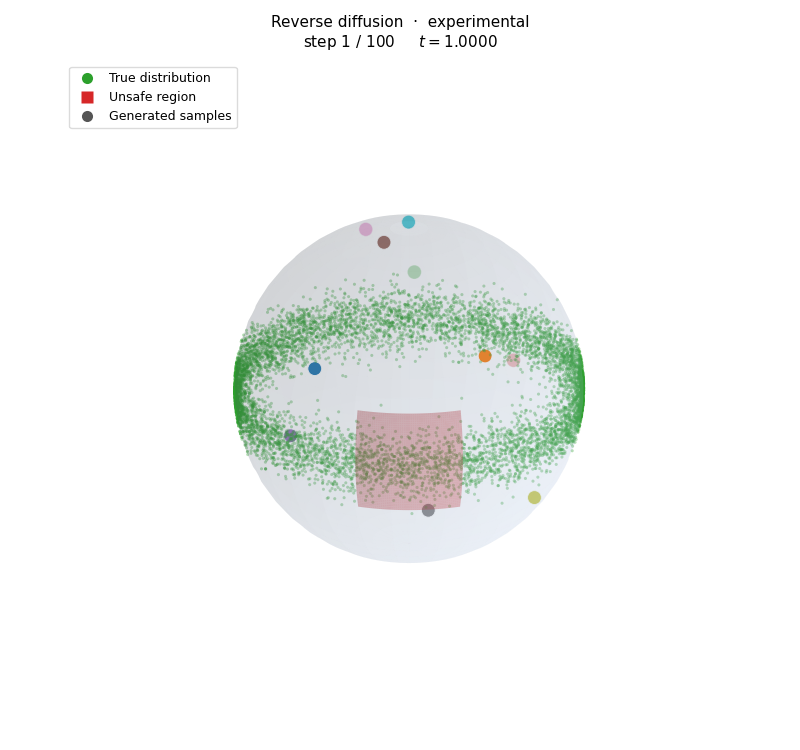

In [9]:
# ── helpers ───────────────────────────────────────────────────────────────────

def _sphere_mesh(n=60):
    u = np.linspace(0, 2 * np.pi, n)
    v = np.linspace(0, np.pi, n // 2)
    U, V = np.meshgrid(u, v)
    return np.cos(U) * np.sin(V), np.sin(U) * np.sin(V), np.cos(V)


def _unsafe_mesh(phi_min, phi_max, theta_center=np.pi / 2, band_half=0.5, n=50):
    """Azimuthal wedge restricted to a latitudinal band around the data ring."""
    phi   = np.linspace(phi_min, phi_max, n)
    theta = np.linspace(
        np.clip(theta_center - band_half, 0.01, np.pi - 0.01),
        np.clip(theta_center + band_half, 0.01, np.pi - 0.01),
        n,
    )
    P, T = np.meshgrid(phi, theta)
    return np.sin(T) * np.cos(P), np.sin(T) * np.sin(P), np.cos(T)


def _ring_samples(n, theta_center, concentration, seed=42):
    """Sample from the true ring distribution: Gaussian in θ, uniform in φ."""
    rng_r = np.random.default_rng(seed)
    theta = np.clip(
        rng_r.normal(theta_center, 1.0 / np.sqrt(concentration), n),
        0.01, np.pi - 0.01,
    )
    phi = rng_r.uniform(0, 2 * np.pi, n)
    x = np.sin(theta) * np.cos(phi)
    y = np.sin(theta) * np.sin(phi)
    z = np.cos(theta)
    return np.stack([x, y, z], axis=-1)


def _t_at_step(step):
    t = timesteps[step]
    return float(t.flat[0])


# ── geometry derived from config ──────────────────────────────────────────────

_latitude      = float(cfg.dataset.get("latitude", 0.0))
_concentration = float(cfg.dataset.get("concentration", 20.0))
_theta_center  = np.pi / 2 - _latitude
_band_half     = 3.0 / np.sqrt(_concentration)

SX, SY, SZ = _sphere_mesh()
UX, UY, UZ = _unsafe_mesh(PHI_MIN, PHI_MAX, _theta_center, _band_half)

_true_pts = _ring_samples(8000, _theta_center, _concentration)
COLORS    = plt.cm.tab10(np.linspace(0, 1, N_SAMPLES))

# ── camera ────────────────────────────────────────────────────────────────────
_phi_center_deg = float(np.degrees((PHI_MIN + PHI_MAX) / 2))
_elev_deg       = float(np.degrees(np.pi / 2 - _theta_center)) + 25

# ── style constants ───────────────────────────────────────────────────────────
_SPHERE_C = "#aec6e8"   # soft steel blue
_DATA_C   = "#2ca02c"   # muted green
_UNSAFE_C = "#d62728"   # standard red

# ── figure ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(8, 7.5), facecolor="white")
ax  = fig.add_subplot(111, projection="3d")
ax.set_facecolor("white")


def render(step):
    from matplotlib.lines import Line2D

    ax.cla()
    ax.set_facecolor("white")

    # translucent sphere shell
    ax.plot_surface(SX, SY, SZ, color=_SPHERE_C, alpha=0.12, linewidth=0, zorder=1)

    # true data distribution ring
    ax.scatter(
        _true_pts[:, 0], _true_pts[:, 1], _true_pts[:, 2],
        c=_DATA_C, s=5, alpha=0.35, zorder=3, edgecolors="none",
    )

    # unsafe wedge
    ax.plot_surface(UX, UY, UZ, color=_UNSAFE_C, alpha=0.35, linewidth=0, zorder=2)

    # trajectory tails (last 20 steps)
    tail_start = max(0, step - 20)
    for i in range(N_SAMPLES):
        tail = x_hist[tail_start : step + 1, i, :]
        if len(tail) > 1:
            ax.plot(
                tail[:, 0], tail[:, 1], tail[:, 2],
                color=COLORS[i], alpha=0.35, linewidth=1.0, zorder=5,
            )

    # current particle positions
    pts = x_hist[step]
    ax.scatter(
        pts[:, 0], pts[:, 1], pts[:, 2],
        c=COLORS, s=100, edgecolors="white", linewidths=0.7, zorder=10,
    )

    # legend
    legend_handles = [
        Line2D([0], [0], marker="o", color="none",
               markerfacecolor=_DATA_C, markeredgecolor="none",
               markersize=8, label="True distribution"),
        Line2D([0], [0], marker="s", color="none",
               markerfacecolor=_UNSAFE_C, markeredgecolor="none",
               markersize=8, label="Unsafe region"),
        Line2D([0], [0], marker="o", color="none",
               markerfacecolor="#555", markeredgecolor="none",
               markersize=8, label="Generated samples"),
    ]
    ax.legend(
        handles=legend_handles,
        loc="upper left", fontsize=9,
        framealpha=0.7, facecolor="white",
        edgecolor="#cccccc",
    )

    t_val        = _t_at_step(step)
    safety_label = f"  ·  {SAFETY_METHOD}" if USE_SAFETY else ""
    ax.set_title(
        f"Reverse diffusion{safety_label}\n"
        f"step {step + 1} / {N_STEPS}     $t = {t_val:.4f}$",
        fontsize=11, pad=10,
    )

    ax.set_xlim([-1.15, 1.15])
    ax.set_ylim([-1.15, 1.15])
    ax.set_zlim([-1.15, 1.15])
    ax.set_box_aspect([1, 1, 1])
    ax.axis("off")
    ax.view_init(elev=_elev_deg, azim=_phi_center_deg)

    fig.canvas.draw_idle()


# ── widgets ───────────────────────────────────────────────────────────────────
step_slider = widgets.IntSlider(
    value=0, min=0, max=N_STEPS - 1, step=1,
    description="Step:",
    continuous_update=True,
    layout=widgets.Layout(width="70%"),
)
play_btn = widgets.Play(
    value=0, min=0, max=N_STEPS - 1, step=1,
    interval=80,
    description="Play",
)
widgets.jslink((play_btn, "value"), (step_slider, "value"))
step_slider.observe(lambda change: render(change["new"]), names="value")

display(widgets.HBox([play_btn, step_slider]))
render(0)
fig.savefig(os.path.join(PLOTS_DIR, "trajectory_viewer_step0.png"), dpi=150, bbox_inches="tight")
plt.tight_layout()
plt.show()

Pre-computing score velocities along tracked trajectory …
Pre-computing same-noise counterfactual positions …
Done.  |learned| ∈ [0.002, 13.748]   |unsafe| ∈ [0.002, 13.748]   |safe| ∈ [0.002, 18.887]


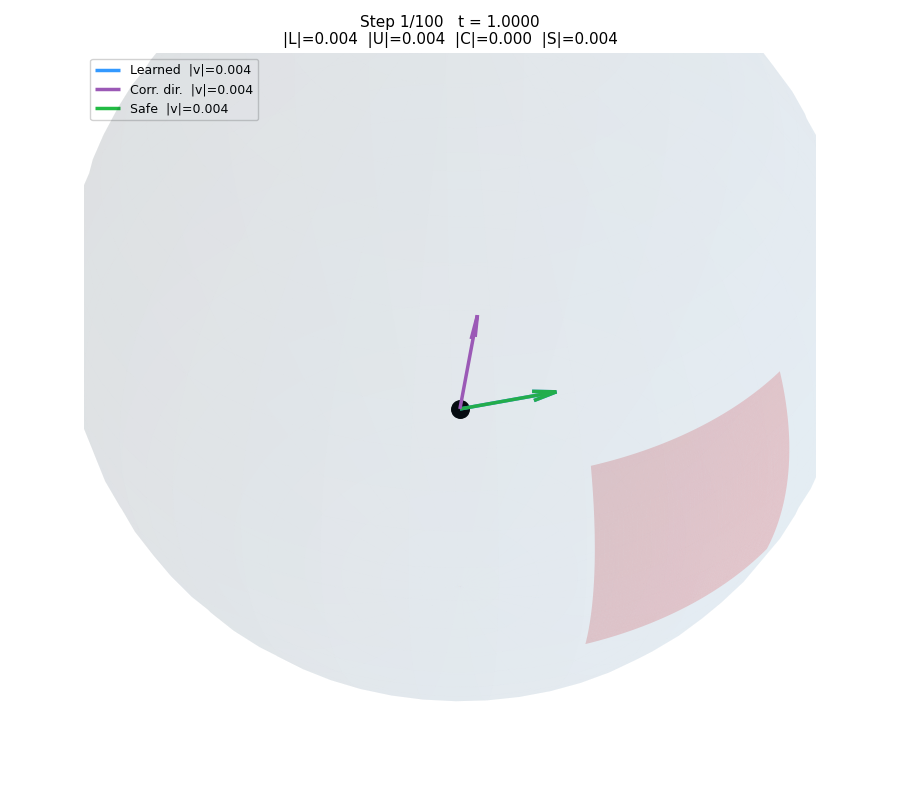

In [10]:
%matplotlib widget

# ═══════════════════════════════════════════════════════════════════════════════
# 7b — Single-sample step-by-step velocity decomposition
#
# Phase A (even sub-steps) — velocity arrows at current position:
#   Blue   (Learned)    : xp  →  xp + vp·scale
#   Purple (Unsafe)     : xp  →  xp + vu·scale   (only when USE_SAFETY=True)
#   Green  (Safe)       : xp  →  xp + vs·scale
#   Orange (Correction) : tip of Learned → tip of Safe  (= vc·scale)
#
# Phase B (odd sub-steps) — what actually happened:
#   Black solid  : actual displacement  xp → xn  (safety ON, actual noise)
#   Blue dashed  : counterfactual       xp → xn_cf  (safety OFF, same noise)
#
# The same-noise counterfactual is computed by replaying the sampler's RNG chain
# (two splits per step: corrector then predictor) to reconstruct the exact z used,
# then re-applying it with score_fn_plain instead of score_fn.
# ═══════════════════════════════════════════════════════════════════════════════

from score_sde.models.flow import log_map_batch, heat_kernel_log

# ── config ────────────────────────────────────────────────────────────────────
SAMPLE_IDX = 0
ZOOM       = 0.50
ARROW_FRAC = 0.45

# ── pre-compute tangent-space velocities ──────────────────────────────────────

_manifold_7b = pushforward.transform.domain
_metric_7b   = _manifold_7b.metric
_n_max_7b    = int(safety_cfg.n_max) if USE_SAFETY else 5

@jax.jit
def _eval_scores(xb, tb):
    """xb [1,3], tb [1]  →  (v_learned [3], v_unsafe [3], v_safe [3])"""
    v_learned = score_fn_plain(xb, tb)[0]

    if not USE_SAFETY:
        return v_learned, jnp.zeros_like(v_learned), v_learned

    # barrier has no log-p-based unsafe score
    if SAFETY_METHOD == "barrier":
        return v_learned, jnp.zeros_like(v_learned), score_fn(xb, tb)[0]

    t_safe   = jnp.clip(tb, 1e-3, None).reshape(-1, 1)
    log_vecs = log_map_batch(xb, unsafe_points, _metric_7b)

    # dispatch kernel to match the active safety method
    if SAFETY_METHOD == "spectral":
        log_p = heat_kernel_log(xb, unsafe_points, t_safe, _manifold_7b, n_max=_n_max_7b)
    elif SAFETY_METHOD == "experimental":
        dist_sq        = jnp.sum(log_vecs**2, axis=-1)
        log_p_varadhan = -dist_sq / (2 * t_safe)
        log_p_spectral = heat_kernel_log(xb, unsafe_points, t_safe, _manifold_7b, n_max=_n_max_7b)
        log_p = jnp.where(jnp.mean(tb) >= 0.5, log_p_spectral, log_p_varadhan)
    else:  # varadhan
        dist_sq = jnp.sum(log_vecs**2, axis=-1)
        log_p   = -dist_sq / (2 * t_safe)

    log_p    = log_p - jnp.max(log_p, axis=1, keepdims=True)
    weights  = jnp.exp(log_p)
    w_sum    = jnp.sum(weights, axis=1, keepdims=True) + 1e-8
    v_unsafe = (jnp.sum(weights[..., None] * log_vecs, axis=1) / w_sum)[0]

    score_norm   = jnp.linalg.norm(v_learned, keepdims=True) + 1e-8
    unsafe_norm  = jnp.linalg.norm(v_unsafe,  keepdims=True) + 1e-8
    v_unsafe_matched = v_unsafe / unsafe_norm * score_norm

    if SAFETY_METHOD == 'experimental':
        # Current formula adds beta * normalize(score - unsafe_score) * score_norm
        correction = v_learned - v_unsafe_matched
        corr_norm  = jnp.linalg.norm(correction, keepdims=True) + 1e-8
        v_unsafe   = correction / corr_norm * score_norm
    else:
        v_unsafe = v_unsafe_matched

    return v_learned, v_unsafe, score_fn(xb, tb)[0]

def _proj_tangent(v, x):
    n = x / (np.linalg.norm(x) + 1e-12)
    return v - np.dot(v, n) * n

def _get_t(i):
    t = timesteps[i]
    idx = min(SAMPLE_IDX, int(np.prod(t.shape)) - 1)
    return float(t.flat[idx])

print("Pre-computing score velocities along tracked trajectory …")
_vp = np.zeros((N_STEPS, 3))
_vu = np.zeros((N_STEPS, 3))
_vs = np.zeros((N_STEPS, 3))

for i in range(N_STEPS):
    xi = jnp.array(x_hist[i, SAMPLE_IDX])
    ti = jnp.array([_get_t(i)])
    vp_i, vu_i, vs_i = _eval_scores(xi[None], ti)
    xn = np.array(xi)
    _vp[i] = _proj_tangent(np.array(vp_i), xn)
    _vu[i] = _proj_tangent(np.array(vu_i), xn)
    _vs[i] = _proj_tangent(np.array(vs_i), xn)

_vc = _vs - _vp

# ── precompute counterfactual positions (plain score, same noise) ─────────────
# The sampler does two random.split calls per step:
#   split 1 → corrector key  (consumed but NoneCorrector ignores it)
#   split 2 → predictor key  (used by GRW to draw the tangent noise z)
# Replaying this chain gives the exact z used at each step.
# Base point for step i = model-space position before step i
#   = transform.inv(x_hist[i-1]) for i>0, or z (initial noise) for i=0.

print("Pre-computing same-noise counterfactual positions …")

plain_rsde  = pushforward.sde.reverse(score_fn_plain)
dt_val      = float(_get_t(1) - _get_t(0))          # signed (negative: t decreasing)
inv_tf      = jax.jit(jax.vmap(pushforward.transform.inv))
x_hist_model = np.array(inv_tf(jnp.array(x_hist)))  # [N_STEPS, N_SAMPLES, 3] in model space

_x_cf = np.zeros((N_STEPS, 3))

rng_replay = sample_rng
for i in range(N_STEPS - 1):
    # Advance RNG to match the sampler's two splits at step i
    rng_replay, _          = jax.random.split(rng_replay)   # corrector split (unused)
    rng_replay, step_rng_i = jax.random.split(rng_replay)   # predictor split

    # Base point: position entering step i (in model space)
    base_i = jnp.array(x_hist_model[i - 1, SAMPLE_IDX] if i > 0 else z[SAMPLE_IDX])[None]

    # Reconstruct the exact noise drawn by GRW at this step
    _, z_i = model_manifold.random_normal_tangent(
        state=step_rng_i, base_point=base_i, n_samples=1
    )
    z_i = z_i.reshape(1, -1)

    # Apply plain score + same noise → counterfactual next position
    t_i            = jnp.ones(1) * _get_t(i)
    drift_i, diff_i = plain_rsde.coefficients(base_i, t_i)
    tangent_cf     = drift_i * dt_val + diff_i * z_i * jnp.sqrt(jnp.abs(dt_val))
    x_cf_i         = model_manifold.exp(tangent_vec=tangent_cf, base_point=base_i)

    _x_cf[i] = np.array(pushforward.transform(x_cf_i[0]))

print(
    f"Done.  |learned| ∈ [{np.linalg.norm(_vp,axis=1).min():.3f}, "
    f"{np.linalg.norm(_vp,axis=1).max():.3f}]   "
    f"|unsafe| ∈ [{np.linalg.norm(_vu,axis=1).min():.3f}, "
    f"{np.linalg.norm(_vu,axis=1).max():.3f}]   "
    f"|safe| ∈ [{np.linalg.norm(_vs,axis=1).min():.3f}, "
    f"{np.linalg.norm(_vs,axis=1).max():.3f}]"
)

# ── sub-step helpers ──────────────────────────────────────────────────────────
N_SUB = 2 * N_STEPS

def _decode(sub):
    step  = min(sub // 2, N_STEPS - 1)
    phase = sub % 2
    if phase == 1 and step >= N_STEPS - 1:
        phase = 0
    return step, phase

# ── figure ────────────────────────────────────────────────────────────────────
fig_v, ax_v = plt.subplots(1, 1, figsize=(9, 8), subplot_kw={"projection": "3d"})

_COLORS = {
    "Learned":    "#3399ff",
    "Unsafe":     "#9b59b6",
    "Correction": "#ff6644",
    "Safe":       "#22bb44",
}

def _quiver(origin, vec, scale, color, label):
    mag = float(np.linalg.norm(vec))
    if mag < 1e-8:
        return
    d = vec * scale
    ax_v.quiver(
        origin[0], origin[1], origin[2],
        d[0], d[1], d[2],
        color=color, linewidth=2.5, arrow_length_ratio=0.25,
        label=f"{label}  |v|={mag:.3f}", zorder=40,
    )

def render_sub(sub):
    ax_v.cla()
    step, phase = _decode(sub)
    xp = x_hist[step, SAMPLE_IDX]
    cx, cy, cz = float(xp[0]), float(xp[1]), float(xp[2])

    focus = xp
    if phase == 1 and step < N_STEPS - 1:
        focus = (xp + x_hist[step + 1, SAMPLE_IDX]) / 2.0
    ax_v.view_init(
        elev=float(np.degrees(np.arcsin(np.clip(focus[2], -1, 1)))) + 15,
        azim=float(np.degrees(np.arctan2(focus[1], focus[0]))),
    )

    ax_v.set_xlim([cx - ZOOM, cx + ZOOM])
    ax_v.set_ylim([cy - ZOOM, cy + ZOOM])
    ax_v.set_zlim([cz - ZOOM, cz + ZOOM])
    ax_v.set_box_aspect([1, 1, 1])
    ax_v.axis("off")
    ax_v.plot_surface(SX, SY, SZ, color="steelblue", alpha=0.07, linewidth=0)
    ax_v.plot_surface(UX, UY, UZ, color="red",       alpha=0.18, linewidth=0)

    t0_idx = max(0, step - 10)
    tail = x_hist[t0_idx : step + 1, SAMPLE_IDX]
    if len(tail) > 1:
        ax_v.plot(tail[:, 0], tail[:, 1], tail[:, 2],
                  color="gray", alpha=0.45, linewidth=1.0, linestyle="--")

    # ── phase A: velocity arrows ──────────────────────────────────────────────
    if phase == 0:
        ax_v.scatter(cx, cy, cz, color="black", s=160, zorder=30)

        vp, vu, vc, vs = _vp[step], _vu[step], _vc[step], _vs[step]
        step_max = max(np.linalg.norm(vp), np.linalg.norm(vs), 1e-8)
        scale    = ARROW_FRAC * ZOOM / step_max

        _quiver(xp, vp, scale, _COLORS["Learned"],    "Learned")
        _unsafe_label = "Corr. dir." if SAFETY_METHOD == "experimental" else "Unsafe"
        if USE_SAFETY:
            _quiver(xp, vu, scale, _COLORS["Unsafe"], _unsafe_label)
        _quiver(xp, vs, scale, _COLORS["Safe"],        "Safe")
        _quiver(xp + vp * scale, vc, scale, _COLORS["Correction"], "Correction")

        ax_v.legend(loc="upper left", fontsize=9, framealpha=0.88)
        vu_str = f"  |U|={np.linalg.norm(vu):.3f}" if USE_SAFETY else ""
        ax_v.set_title(
            f"Step {step + 1}/{N_STEPS}   t = {_get_t(step):.4f}\n"
            f"|L|={np.linalg.norm(vp):.3f}{vu_str}  "
            f"|C|={np.linalg.norm(vc):.3f}  |S|={np.linalg.norm(vs):.3f}",
            fontsize=11,
        )

    # ── phase B: actual + counterfactual displacement ─────────────────────────
    else:
        xn    = x_hist[step + 1, SAMPLE_IDX]      # actual next position (safety ON)
        xn_cf = _x_cf[step]                        # counterfactual (plain score, same noise)

        disp    = xn    - xp
        disp_cf = xn_cf - xp
        disp_mag    = float(np.linalg.norm(disp))
        disp_cf_mag = float(np.linalg.norm(disp_cf))

        scale = ARROW_FRAC * ZOOM / max(disp_mag, disp_cf_mag, 1e-8)

        ax_v.scatter(cx, cy, cz, color="gray", s=80, alpha=0.35, zorder=20)

        # actual (black solid)
        ax_v.scatter(xn[0], xn[1], xn[2], color="black", s=120, zorder=30)
        if disp_mag > 1e-8:
            ax_v.quiver(cx, cy, cz,
                        disp[0]*scale, disp[1]*scale, disp[2]*scale,
                        color="black", linewidth=2.5, arrow_length_ratio=0.25,
                        label=f"Actual (safety ON)  |Δx|={disp_mag:.4f}", zorder=35)

        # counterfactual (blue dashed)
        ax_v.scatter(xn_cf[0], xn_cf[1], xn_cf[2],
                     color=_COLORS["Learned"], s=80, marker="^", alpha=0.85, zorder=30)
        if disp_cf_mag > 1e-8:
            ax_v.quiver(cx, cy, cz,
                        disp_cf[0]*scale, disp_cf[1]*scale, disp_cf[2]*scale,
                        color=_COLORS["Learned"], linewidth=2.0, arrow_length_ratio=0.25,
                        linestyle="dashed", alpha=0.85,
                        label=f"No safety (same noise)  |Δx|={disp_cf_mag:.4f}", zorder=34)

        ax_v.legend(loc="upper left", fontsize=8, framealpha=0.88)
        ax_v.set_title(
            f"Step {step + 1}/{N_STEPS}   t: {_get_t(step):.4f} → {_get_t(step+1):.4f}\n"
            f"Actual |Δx|={disp_mag:.4f}   No-safety |Δx|={disp_cf_mag:.4f}",
            fontsize=11,
        )

    fig_v.canvas.draw_idle()

# ── widgets ───────────────────────────────────────────────────────────────────
_sl_v = widgets.IntSlider(
    value=0, min=0, max=N_SUB - 1, step=1,
    description="Sub-step:",
    continuous_update=True,
    layout=widgets.Layout(width="70%"),
)
_pl_v = widgets.Play(
    value=0, min=0, max=N_SUB - 1, step=1,
    interval=500, description="Play",
)
widgets.jslink((_pl_v, "value"), (_sl_v, "value"))
_sl_v.observe(lambda c: render_sub(c["new"]), names="value")

display(widgets.HBox([_pl_v, _sl_v]))
render_sub(0)
fig_v.savefig(os.path.join(PLOTS_DIR, "velocity_decomposition_step0.png"), dpi=150, bbox_inches="tight")
plt.tight_layout()
plt.show()

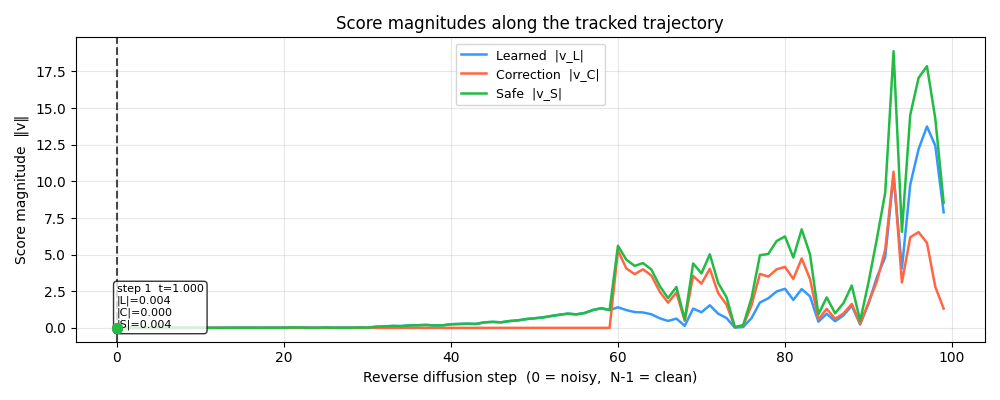

In [11]:
%matplotlib widget

# ═══════════════════════════════════════════════════════════════════════════════
# 7c — Magnitude time-series viewer
#
# Shows |learned|, |correction|, |safe| across all reverse-diffusion steps.
# The vertical cursor follows the slider and highlights the current step.
# Requires cell 7b to have been run first (_vp, _vc, _vs must be defined).
# ═══════════════════════════════════════════════════════════════════════════════

# Pre-compute scalar magnitudes (already have the vectors from 7b)
_mag_p = np.linalg.norm(_vp, axis=1)   # [N_STEPS]  learned
_mag_c = np.linalg.norm(_vc, axis=1)   # [N_STEPS]  correction
_mag_s = np.linalg.norm(_vs, axis=1)   # [N_STEPS]  safe

_steps   = np.arange(N_STEPS)
_t_vals  = np.array([_get_t(i) for i in range(N_STEPS)])   # decreasing t

# ── figure ────────────────────────────────────────────────────────────────────
fig_m, ax_m = plt.subplots(figsize=(10, 4))

ax_m.plot(_steps, _mag_p, color="#3399ff", linewidth=1.8, label="Learned  |v_L|")
ax_m.plot(_steps, _mag_c, color="#ff6644", linewidth=1.8, label="Correction  |v_C|")
ax_m.plot(_steps, _mag_s, color="#22bb44", linewidth=1.8, label="Safe  |v_S|")

# t_min threshold line (safety inactive below this t)
if USE_SAFETY and hasattr(safety_cfg, "t_min"):
    # find step where t crosses t_min
    t_min_val = float(safety_cfg.t_min)
    crossings = np.where(np.diff((_t_vals > t_min_val).astype(int)))[0]
    if len(crossings):
        ax_m.axvline(crossings[0], color="gray", linestyle=":", linewidth=1.2,
                     label=f"t = t_min = {t_min_val}")

ax_m.set_xlabel("Reverse diffusion step  (0 = noisy,  N-1 = clean)")
ax_m.set_ylabel("Score magnitude  ‖v‖")
ax_m.set_title("Score magnitudes along the tracked trajectory")
ax_m.legend(fontsize=9)
ax_m.grid(True, alpha=0.3)

# Moving cursor
_cursor = ax_m.axvline(0, color="black", linewidth=1.5, linestyle="--", alpha=0.7)

# Dot markers at the cursor position
_dot_p, = ax_m.plot([0], [_mag_p[0]], "o", color="#3399ff", ms=7, zorder=5)
_dot_c, = ax_m.plot([0], [_mag_c[0]], "o", color="#ff6644", ms=7, zorder=5)
_dot_s, = ax_m.plot([0], [_mag_s[0]], "o", color="#22bb44", ms=7, zorder=5)

# Value annotation
_ann = ax_m.annotate(
    "", xy=(0, 0),
    xytext=(8, 8), textcoords="offset points",
    fontsize=8, color="black",
    bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8),
)

def _update_cursor(step):
    _cursor.set_xdata([step, step])
    _dot_p.set_data([step], [_mag_p[step]])
    _dot_c.set_data([step], [_mag_c[step]])
    _dot_s.set_data([step], [_mag_s[step]])
    _ann.set_position((step, max(_mag_p[step], _mag_c[step], _mag_s[step])))
    _ann.set_text(
        f"step {step + 1}  t={_get_t(step):.3f}\n"
        f"|L|={_mag_p[step]:.3f}\n"
        f"|C|={_mag_c[step]:.3f}\n"
        f"|S|={_mag_s[step]:.3f}"
    )
    fig_m.canvas.draw_idle()

# ── widget ────────────────────────────────────────────────────────────────────
_sl_m = widgets.IntSlider(
    value=0, min=0, max=N_STEPS - 1, step=1,
    description="Step:",
    continuous_update=True,
    layout=widgets.Layout(width="70%"),
)
_pl_m = widgets.Play(
    value=0, min=0, max=N_STEPS - 1, step=1,
    interval=120,
    description="Play",
)
widgets.jslink((_pl_m, "value"), (_sl_m, "value"))
_sl_m.observe(lambda c: _update_cursor(c["new"]), names="value")

display(widgets.HBox([_pl_m, _sl_m]))
_update_cursor(0)
fig_m.savefig(os.path.join(PLOTS_DIR, "score_magnitudes_timeseries.png"), dpi=150, bbox_inches="tight")
plt.tight_layout()
plt.show()

In [12]:
import pandas as pd

# ── reuse vectors already computed in cell 7b ─────────────────────────────────
# _vp, _vu, _vs, _vc are the projected tangent vectors from the actual reverse
# diffusion run — they reflect whichever safety method was active in section 6.
_vp_tbl = _vp
_vu_tbl = _vu
_vs_tbl = _vs
_vc_tbl = _vc

# ── geodesic distances ────────────────────────────────────────────────────────
_up = np.array(unsafe_points)

def _dist_to_ring(x):
    theta_x = float(np.arccos(np.clip(x[2], -1.0, 1.0)))
    return abs(theta_x - _theta_center)

def _dist_to_unsafe(x):
    dots = np.clip(_up @ x, -1.0, 1.0)
    return float(np.min(np.arccos(dots)))

# ── build table ───────────────────────────────────────────────────────────────
rows = []
for i in range(N_STEPS):
    xi = x_hist[i, SAMPLE_IDX]
    rows.append({
        "Step":          i + 1,
        "t":             round(_get_t(i), 4),
        "|v_L| learned": round(float(np.linalg.norm(_vp_tbl[i])), 4),
        "|v_U| unsafe":  round(float(np.linalg.norm(_vu_tbl[i])), 4),
        "|v_C| corr":    round(float(np.linalg.norm(_vc_tbl[i])), 4),
        "|v_S| safe":    round(float(np.linalg.norm(_vs_tbl[i])), 4),
        "d_ring":        round(_dist_to_ring(xi), 4),
        "d_unsafe_pts":  round(_dist_to_unsafe(xi), 4),
    })

df = pd.DataFrame(rows).set_index("Step")

print(f"\nSample index: {SAMPLE_IDX}   (safety = {USE_SAFETY},  method = {SAFETY_METHOD if USE_SAFETY else 'none'})\n")
df


Sample index: 0   (safety = True,  method = experimental)



,t,|v_L| learned,|v_U| unsafe,|v_C| corr,|v_S| safe,d_ring,d_unsafe_pts
Step,,,,,,,
1,1.0000,0.0038,0.0038,0.0000,0.0038,0.4762,0.5268
2,0.9899,0.0024,0.0024,0.0000,0.0024,0.1567,0.4211
3,0.9798,0.0029,0.0029,0.0000,0.0029,0.0043,0.2255
4,0.9697,0.0035,0.0035,0.0000,0.0035,0.0244,0.1626
5,0.9596,0.0040,0.0040,0.0000,0.0040,0.0174,0.0219
...,...,...,...,...,...,...,...
96,0.0414,9.7830,9.7830,6.1888,14.5379,0.1479,0.5867
97,0.0313,12.2082,12.2082,6.5337,17.0653,0.1626,0.5601
98,0.0212,13.7479,13.7479,5.8007,17.8645,0.1638,0.5093


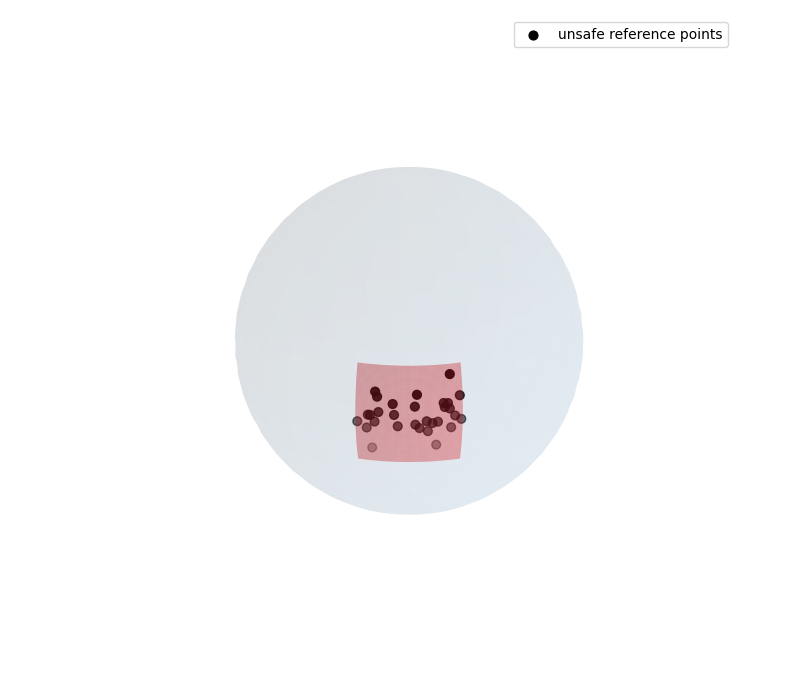

In [13]:
fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection="3d")

# sphere
ax.plot_surface(
    SX, SY, SZ,
    color="steelblue",
    alpha=0.08,
    linewidth=0,
)

# red unsafe patch currently visualized
ax.plot_surface(
    UX, UY, UZ,
    color="red",
    alpha=0.35,
    linewidth=0,
)

# unsafe reference points actually used by safety methods
up = np.array(unsafe_points)

ax.scatter(
    up[:, 0],
    up[:, 1],
    up[:, 2],
    c="black",
    s=40,
    label="unsafe reference points",
)

ax.legend()

ax.set_box_aspect([1, 1, 1])
ax.axis("off")
ax.view_init(elev=_elev_deg, azim=_phi_center_deg)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "unsafe_reference_points.png"), dpi=150, bbox_inches="tight")
plt.show()

## 8 — Side-by-side: safe vs unsafe

Run the sampler a second time **without** safety, then show both final distributions.

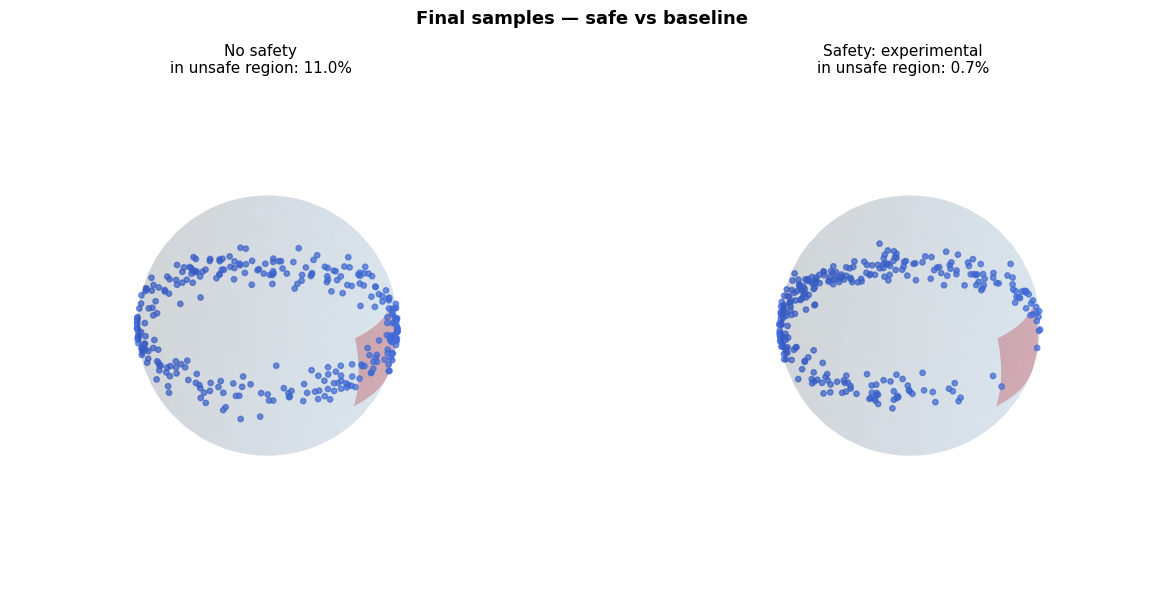

In [14]:
%matplotlib inline
plt.close("all")

# Baseline: plain score function (no safety)
score_fn_plain = pushforward.sde.reparametrise_score_fn(*model_w_dicts)
score_fn_plain = partial(score_fn_plain, context=None)
reverse_sde_plain = pushforward.sde.reverse(score_fn_plain)

sampler_plain = jax.jit(get_pc_sampler(
    reverse_sde_plain,
    unsafe_points=None, safety_cfg=None,
    N=N_STEPS, predictor="GRW", eps=EPS, return_hist=False,
))

N_BIG = 300
z_big   = pushforward.base.sample(jax.random.PRNGKey(1), (N_BIG,))
x_plain = np.array(jax.vmap(pushforward.transform)(sampler_plain(jax.random.PRNGKey(1), z_big)))

# Safe run (reuse x_final from above, but with more samples)
if USE_SAFETY:
    sampler_safe = jax.jit(get_pc_sampler(
        pushforward.sde.reverse(score_fn),   # score_fn already has safety
        unsafe_points=None, safety_cfg=None,
        N=N_STEPS, predictor="GRW", eps=EPS, return_hist=False,
    ))
    z_big2  = pushforward.base.sample(jax.random.PRNGKey(2), (N_BIG,))
    x_safe  = np.array(jax.vmap(pushforward.transform)(sampler_safe(jax.random.PRNGKey(2), z_big2)))
else:
    x_safe = x_plain

# ── plot ──────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 6), subplot_kw={"projection": "3d"})

for ax, pts, title in zip(
    axes,
    [x_plain, x_safe],
    ["No safety", f"Safety: {SAFETY_METHOD}" if USE_SAFETY else "No safety (same)"],
):
    ax.plot_surface(SX, SY, SZ, color="steelblue", alpha=0.10, linewidth=0)
    ax.plot_surface(UX, UY, UZ, color="red",       alpha=0.30, linewidth=0)
    ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=15, alpha=0.7, c="royalblue")

    phi = np.arctan2(pts[:, 1], pts[:, 0])
    pct = 100 * np.mean((phi > PHI_MIN) & (phi < PHI_MAX))
    ax.set_title(f"{title}\nin unsafe region: {pct:.1f}%", fontsize=11)
    ax.set_box_aspect([1, 1, 1])
    ax.axis("off")

plt.suptitle("Final samples — safe vs baseline", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "safe_vs_unsafe_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()

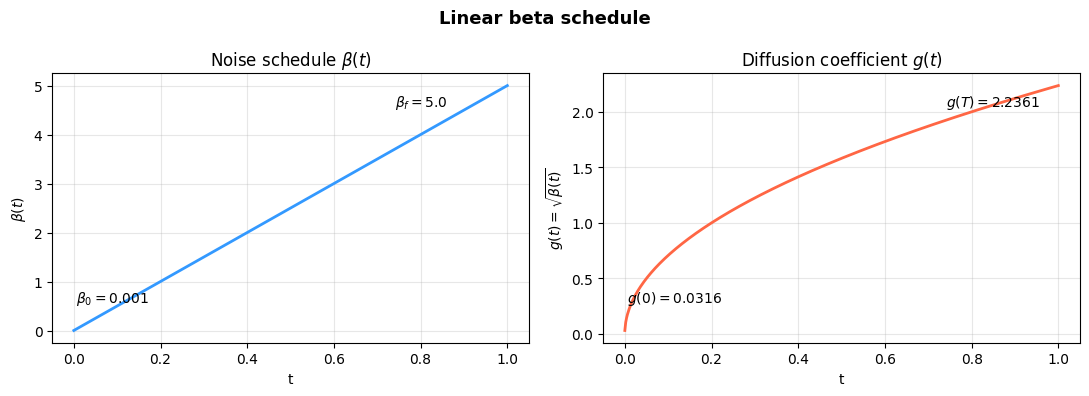

In [15]:
%matplotlib inline

t_vals = np.linspace(beta_schedule.t0, beta_schedule.tf, 500)
beta_vals = np.array([float(beta_schedule.beta_t(jnp.array(t))) for t in t_vals])
g_vals = np.sqrt(beta_vals)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(t_vals, beta_vals, color="#3399ff", linewidth=2)
axes[0].set_xlabel("t")
axes[0].set_ylabel(r"$\beta(t)$")
axes[0].set_title(r"Noise schedule $\beta(t)$")
axes[0].annotate(f"$\\beta_0 = {beta_schedule.beta_0}$", xy=(t_vals[0], beta_vals[0]),
                 xytext=(0.05, 0.15), textcoords="axes fraction", fontsize=10)
axes[0].annotate(f"$\\beta_f = {beta_schedule.beta_f}$", xy=(t_vals[-1], beta_vals[-1]),
                 xytext=(0.72, 0.88), textcoords="axes fraction", fontsize=10)
axes[0].grid(True, alpha=0.3)

axes[1].plot(t_vals, g_vals, color="#ff6644", linewidth=2)
axes[1].set_xlabel("t")
axes[1].set_ylabel(r"$g(t) = \sqrt{\beta(t)}$")
axes[1].set_title(r"Diffusion coefficient $g(t)$")
axes[1].annotate(f"$g(0) = {g_vals[0]:.4f}$", xy=(t_vals[0], g_vals[0]),
                 xytext=(0.05, 0.15), textcoords="axes fraction", fontsize=10)
axes[1].annotate(f"$g(T) = {g_vals[-1]:.4f}$", xy=(t_vals[-1], g_vals[-1]),
                 xytext=(0.72, 0.88), textcoords="axes fraction", fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.suptitle("Linear beta schedule", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "beta_schedule.png"), dpi=150, bbox_inches="tight")
plt.show()

Computing score magnitudes …


INFO: Substituting symbol M from STIXNonUnicode
INFO: Substituting symbol M from STIXNonUnicode
INFO: Substituting symbol M from STIXNonUnicode
INFO: Substituting symbol M from STIXNonUnicode
INFO: Substituting symbol M from STIXNonUnicode
INFO: Substituting symbol M from STIXNonUnicode
INFO: Substituting symbol M from STIXNonUnicode
INFO: Substituting symbol M from STIXNonUnicode
INFO: Substituting symbol M from STIXNonUnicode
INFO: Substituting symbol M from STIXNonUnicode


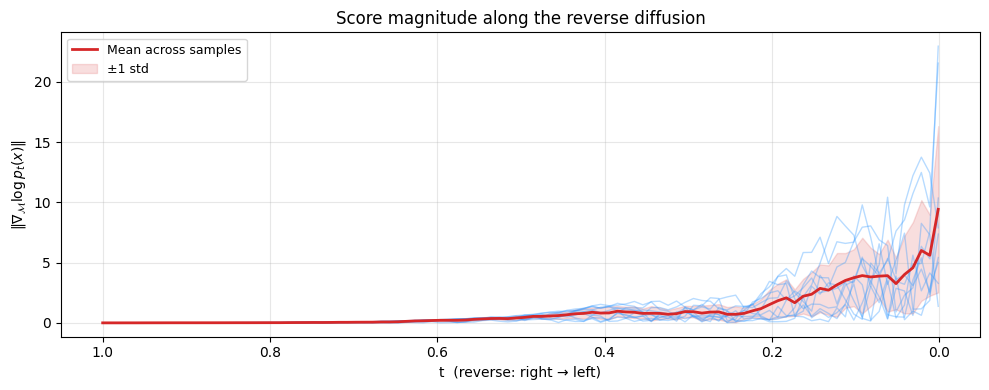

In [16]:
%matplotlib inline

# Compute score magnitude at each reverse diffusion step for all tracked samples
@jax.jit
def _score_magnitude(x, t):
    return jnp.linalg.norm(score_fn_plain(x[None], t[None])[0])

print("Computing score magnitudes …")
_t_axis = np.array([float(timesteps[i].flat[0]) for i in range(N_STEPS)])
_score_mags = np.zeros((N_STEPS, N_SAMPLES))

for i in range(N_STEPS):
    ti = jnp.array([_t_axis[i]])
    for s in range(N_SAMPLES):
        xi = jnp.array(x_hist[i, s])
        _score_mags[i, s] = float(_score_magnitude(xi, ti))

_mean_mag = _score_mags.mean(axis=1)
_std_mag  = _score_mags.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 4))

for s in range(N_SAMPLES):
    ax.plot(_t_axis, _score_mags[:, s], alpha=0.35, linewidth=1.0, color="#3399ff")

ax.plot(_t_axis, _mean_mag, color="#d62728", linewidth=2.0, label="Mean across samples")
ax.fill_between(_t_axis, _mean_mag - _std_mag, _mean_mag + _std_mag,
                alpha=0.15, color="#d62728", label="±1 std")

ax.set_xlabel("t  (reverse: right → left)")
ax.set_ylabel(r"$\|\nabla_{\mathcal{M}} \log p_t(x)\|$")
ax.set_title("Score magnitude along the reverse diffusion")
ax.invert_xaxis()
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "score_magnitude_along_trajectory.png"), dpi=150, bbox_inches="tight")
plt.show()

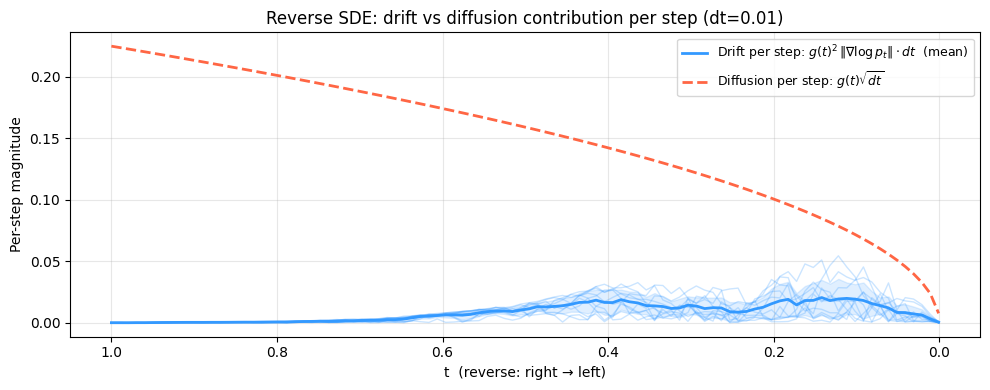

In [17]:
%matplotlib inline
# Two terms of the reverse SDE:  dY = {-b(Y) + g(t)²·score} dt  +  g(t)·dB
#   drift contribution per step     : g(t)² * ||score(x,t)|| * dt
#   diffusion contribution per step : g(t) * sqrt(dt)
dt = abs(_t_axis[1] - _t_axis[0])  # assumes uniform spacing in _t_axis

_drift_mags = np.zeros((N_STEPS, N_SAMPLES))
for i in range(N_STEPS):
    ti = jnp.array([_t_axis[i]])
    g2 = float(beta_schedule.beta_t(jnp.array(_t_axis[i])))   # g(t)² = β(t)
    for s in range(N_SAMPLES):
        _drift_mags[i, s] = g2 * _score_mags[i, s] * dt        # <-- per-step drift

_g_vals = np.sqrt(np.array([float(beta_schedule.beta_t(jnp.array(t))) for t in _t_axis]))
_diffusion_vals = _g_vals * np.sqrt(dt)                          # <-- per-step diffusion

_drift_mean = _drift_mags.mean(axis=1)
_drift_std  = _drift_mags.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 4))
# drift term (per-step)
for s in range(N_SAMPLES):
    ax.plot(_t_axis, _drift_mags[:, s], alpha=0.25, linewidth=1.0, color="#3399ff")
ax.plot(_t_axis, _drift_mean, color="#3399ff", linewidth=2.0,
        label=r"Drift per step: $g(t)^2\,\|\nabla\log p_t\|\cdot dt$  (mean)")
ax.fill_between(_t_axis, _drift_mean - _drift_std, _drift_mean + _drift_std,
                alpha=0.15, color="#3399ff")
# diffusion term (per-step)
ax.plot(_t_axis, _diffusion_vals, color="#ff6644", linewidth=2.0, linestyle="--",
        label=r"Diffusion per step: $g(t)\sqrt{dt}$")
ax.set_xlabel("t  (reverse: right → left)")
ax.set_ylabel("Per-step magnitude")
ax.set_title(f"Reverse SDE: drift vs diffusion contribution per step (dt={dt:.2g})")
ax.invert_xaxis()
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "drift_vs_diffusion_per_step.png"), dpi=150, bbox_inches="tight")
plt.show()

Computing safe score magnitudes …


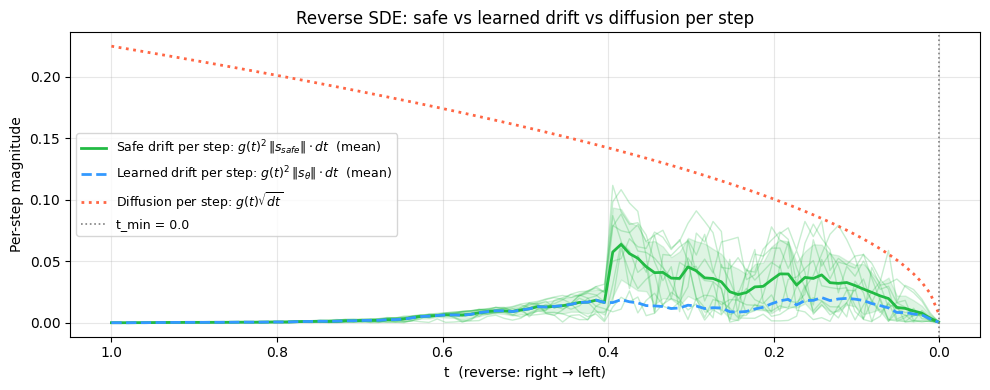

In [18]:
%matplotlib inline

# Compute safe score magnitudes along the tracked trajectory
@jax.jit
def _safe_score_magnitude(x, t):
    return jnp.linalg.norm(score_fn(x[None], t[None])[0])

print('Computing safe score magnitudes …')
_safe_score_mags = np.zeros((N_STEPS, N_SAMPLES))
for i in range(N_STEPS):
    ti = jnp.array([_t_axis[i]])
    for s in range(N_SAMPLES):
        xi = jnp.array(x_hist[i, s])
        _safe_score_mags[i, s] = _safe_score_magnitude(xi, ti)

# Per-step drift magnitudes using safe score
_safe_drift_mags = np.zeros((N_STEPS, N_SAMPLES))
for i in range(N_STEPS):
    g2 = float(beta_schedule.beta_t(jnp.array(_t_axis[i])))
    for s in range(N_SAMPLES):
        _safe_drift_mags[i, s] = g2 * _safe_score_mags[i, s] * dt

_safe_drift_mean  = _safe_drift_mags.mean(axis=1)
_safe_drift_std   = _safe_drift_mags.std(axis=1)
_plain_drift_mean = _drift_mags.mean(axis=1)

fig, ax = plt.subplots(figsize=(10, 4))

# Safe drift per step
for s in range(N_SAMPLES):
    ax.plot(_t_axis, _safe_drift_mags[:, s], alpha=0.25, linewidth=1.0, color='#22bb44')
ax.plot(_t_axis, _safe_drift_mean, color='#22bb44', linewidth=2.0,
        label=r'Safe drift per step: $g(t)^2\,\|s_{safe}\|\cdot dt$  (mean)')
ax.fill_between(_t_axis, _safe_drift_mean - _safe_drift_std, _safe_drift_mean + _safe_drift_std,
                alpha=0.15, color='#22bb44')

# Learned drift per step for reference
ax.plot(_t_axis, _plain_drift_mean, color='#3399ff', linewidth=2.0, linestyle='--',
        label=r'Learned drift per step: $g(t)^2\,\|s_\theta\|\cdot dt$  (mean)')

# Diffusion per step
ax.plot(_t_axis, _diffusion_vals, color='#ff6644', linewidth=2.0, linestyle=':',
        label=r'Diffusion per step: $g(t)\sqrt{dt}$')

if USE_SAFETY and hasattr(safety_cfg, 't_min'):
    ax.axvline(float(safety_cfg.t_min), color='gray', linestyle=':', linewidth=1.2,
               label=f't_min = {float(safety_cfg.t_min)}')

ax.set_xlabel('t  (reverse: right → left)')
ax.set_ylabel('Per-step magnitude')
ax.set_title(f'Reverse SDE: safe vs learned drift vs diffusion per step')
ax.invert_xaxis()
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'safe_drift_vs_diffusion.png'), dpi=150, bbox_inches='tight')
plt.show()


Safety: ON — experimental
Unsafe region: φ ∈ [-0.300, 0.300]
Samples in unsafe region: 2 / 500  (0.4%)


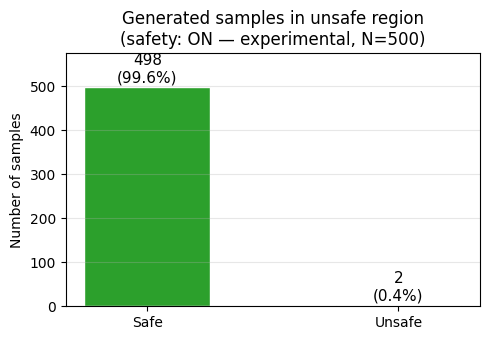

In [19]:
%matplotlib inline

N_EVAL = 500   # number of samples to generate for the evaluation

rng, eval_rng = jax.random.split(rng)
z_eval = pushforward.base.sample(eval_rng, (N_EVAL,))

reverse_sde_eval = pushforward.sde.reverse(score_fn)
sampler_eval = jax.jit(get_pc_sampler(
    reverse_sde_eval,
    unsafe_points=None, safety_cfg=None,
    N=N_STEPS, predictor="GRW", eps=EPS, return_hist=False,
))
x_eval = np.array(jax.vmap(pushforward.transform)(sampler_eval(eval_rng, z_eval)))

phi_eval = np.arctan2(x_eval[:, 1], x_eval[:, 0])
in_unsafe = (phi_eval > PHI_MIN) & (phi_eval < PHI_MAX)
n_unsafe  = int(in_unsafe.sum())
pct       = 100.0 * n_unsafe / N_EVAL

print(f"Safety: {'ON — ' + SAFETY_METHOD if USE_SAFETY else 'OFF'}")
print(f"Unsafe region: φ ∈ [{PHI_MIN:.3f}, {PHI_MAX:.3f}]")
print(f"Samples in unsafe region: {n_unsafe} / {N_EVAL}  ({pct:.1f}%)")

# ── bar chart ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 3.5))

bars = ax.bar(["Safe", "Unsafe"], [N_EVAL - n_unsafe, n_unsafe],
              color=["#2ca02c", "#d62728"], edgecolor="white", width=0.5)

for bar, val in zip(bars, [N_EVAL - n_unsafe, n_unsafe]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 4,
            f"{val}\n({100*val/N_EVAL:.1f}%)", ha="center", va="bottom", fontsize=11)

ax.set_ylabel("Number of samples")
ax.set_title(
    f"Generated samples in unsafe region\n"
    f"(safety: {'ON — ' + SAFETY_METHOD if USE_SAFETY else 'OFF'}, N={N_EVAL})"
)
ax.set_ylim(0, N_EVAL * 1.15)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "unsafe_region_bar.png"), dpi=150, bbox_inches="tight")
plt.show()

## 10 — Safety method sweep: MMD and ASR

Four combinations of kernel × scaling, swept over `eta` and `t_min`.
- **Spectral**: heat-kernel weights; `t_min ∈ {0.5, 0.7, 0.9}` (safety disabled for `t < t_min`)
- **Experimental**: hybrid kernel (spectral for `t ≥ 0.5`, Varadhan for `t < 0.5`); always active (`t_min = 0.0`)
- **Unscaled**: raw log-map vectors fed into the correction formula
- **Scaled**: `unsafe_score` magnitude-matched to `‖score‖`, output renormalised back to `‖score‖`

MMD uses the **full generated distribution** as P and the **real data restricted to the safe region** as Q.
Unsafe generated samples are penalised via small cross-kernel values k(x_gen, y_safe), correctly pulling MMD up.

In [25]:
import pandas as pd
from score_sde.models.flow import log_map_batch, heat_kernel_log

N_EVAL_TABLE      = 500
T_MAX_EXPERIMENTAL = 0.2   # upper t gate for experimental method
ETA_VALUES     = [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0]
T_MIN_SPECTRAL = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

# Reference real data for MMD — restricted to safe region.
# Q = true data | safe, so MMD measures how well the full generated
# distribution covers the safe reference.
_ref_ds      = instantiate(cfg.dataset, rng=jax.random.PRNGKey(cfg.seed))
x_real_all   = np.array(_ref_ds.data[:2000])
_phi_ref     = np.arctan2(x_real_all[:, 1], x_real_all[:, 0])
x_real_ref   = x_real_all[(_phi_ref <= PHI_MIN) | (_phi_ref >= PHI_MAX)]

def _mmd_geodesic(x_gen, x_real, n_sub=2000):
    x = np.array(x_gen[:n_sub])
    y = np.array(x_real[:n_sub])
    def gdist(a, b):
        return np.arccos(np.clip(a @ b.T, -1.0, 1.0))
    bw = float(np.median(gdist(x[:200], y[:200]).ravel()))
    if bw < 1e-6:
        bw = 1.0
    def k(a, b):
        return np.exp(-gdist(a, b) ** 2 / (2 * bw ** 2))
    mmd2 = k(x, x).mean() - 2 * k(x, y).mean() + k(y, y).mean()
    return float(np.sqrt(max(mmd2, 0.0)))

def _run_eval(safe_score_fn, n_eval=N_EVAL_TABLE, seed=42):
    rsde    = pushforward.sde.reverse(safe_score_fn)
    sampler = jax.jit(get_pc_sampler(
        rsde, unsafe_points=None, safety_cfg=None,
        N=N_STEPS, predictor="GRW", eps=EPS, return_hist=False,
    ))
    z_e = pushforward.base.sample(jax.random.PRNGKey(seed), (n_eval,))
    x_e = np.array(jax.vmap(pushforward.transform)(sampler(jax.random.PRNGKey(seed), z_e)))
    phi_e       = np.arctan2(x_e[:, 1], x_e[:, 0])
    unsafe_mask = (phi_e > PHI_MIN) & (phi_e < PHI_MAX)
    asr         = float(np.mean(unsafe_mask))
    # Full generated distribution vs safe-only real reference
    mmd         = _mmd_geodesic(x_e, x_real_ref) if len(x_real_ref) > 10 else float("nan")
    return mmd, asr

_manifold = pushforward.transform.domain
_metric   = _manifold.metric
_beta_max = float(cfg.safety.beta_max)
_n_max    = int(cfg.safety.n_max)

def _make_spectral_unscaled(eta, t_min):
    def sfn(y, t):
        score    = score_fn_plain(y, t)
        t_safe   = jnp.clip(t, 1e-3, None).reshape(-1, 1)
        log_vecs = log_map_batch(y, unsafe_points, _metric)
        log_p    = heat_kernel_log(y, unsafe_points, t_safe, _manifold, n_max=_n_max)
        log_p    = log_p - jnp.max(log_p, axis=1, keepdims=True)
        weights  = jnp.exp(log_p)
        w_sum    = jnp.sum(weights, axis=1, keepdims=True) + 1e-8
        u_score  = jnp.sum(weights[..., None] * log_vecs, axis=1) / w_sum
        beta     = jnp.clip(eta * (1.0 / unsafe_points.shape[0]) * w_sum, 0.0, _beta_max)
        safe     = (1.0 + beta) * score - beta * u_score
        return jnp.where(jnp.mean(t) < t_min, score, safe)
    return sfn

def _make_spectral_scaled(eta, t_min):
    def sfn(y, t):
        score    = score_fn_plain(y, t)
        t_safe   = jnp.clip(t, 1e-3, None).reshape(-1, 1)
        log_vecs = log_map_batch(y, unsafe_points, _metric)
        log_p    = heat_kernel_log(y, unsafe_points, t_safe, _manifold, n_max=_n_max)
        log_p    = log_p - jnp.max(log_p, axis=1, keepdims=True)
        weights  = jnp.exp(log_p)
        w_sum    = jnp.sum(weights, axis=1, keepdims=True) + 1e-8
        u_score  = jnp.sum(weights[..., None] * log_vecs, axis=1) / w_sum
        s_norm   = jnp.linalg.norm(score,   axis=-1, keepdims=True) + 1e-8
        u_norm   = jnp.linalg.norm(u_score, axis=-1, keepdims=True) + 1e-8
        u_score  = u_score / u_norm * s_norm
        beta     = jnp.clip(eta * (1.0 / unsafe_points.shape[0]) * w_sum, 0.0, _beta_max)
        corr     = score - u_score
        corr_n   = jnp.linalg.norm(corr, axis=-1, keepdims=True) + 1e-8
        corr     = corr / corr_n * s_norm
        safe     = score + beta * corr
        return jnp.where(jnp.mean(t) < t_min, score, safe)
    return sfn

def _make_experimental_unscaled(eta, t_min, t_max=1.0):
    def sfn(y, t):
        score    = score_fn_plain(y, t)
        t_safe   = jnp.clip(t, 1e-3, None).reshape(-1, 1)
        log_vecs = log_map_batch(y, unsafe_points, _metric)
        dist_sq  = jnp.sum(log_vecs ** 2, axis=-1)
        log_p    = jnp.where(
            jnp.mean(t) >= 0.5,
            heat_kernel_log(y, unsafe_points, t_safe, _manifold, n_max=_n_max),
            -dist_sq / (2 * t_safe),
        )
        log_p    = log_p - jnp.max(log_p, axis=1, keepdims=True)
        weights  = jnp.exp(log_p)
        w_sum    = jnp.sum(weights, axis=1, keepdims=True) + 1e-8
        u_score  = jnp.sum(weights[..., None] * log_vecs, axis=1) / w_sum
        beta     = jnp.clip(eta * (1.0 / unsafe_points.shape[0]) * w_sum, 0.0, _beta_max)
        safe     = (1.0 + beta) * score - beta * u_score
        return jnp.where((jnp.mean(t) < t_min) | (jnp.mean(t) > t_max), score, safe)
    return sfn

def _make_experimental_scaled(eta, t_min, t_max=1.0):
    def sfn(y, t):
        score    = score_fn_plain(y, t)
        t_safe   = jnp.clip(t, 1e-3, None).reshape(-1, 1)
        log_vecs = log_map_batch(y, unsafe_points, _metric)
        dist_sq  = jnp.sum(log_vecs ** 2, axis=-1)
        log_p    = jnp.where(
            jnp.mean(t) >= 0.5,
            heat_kernel_log(y, unsafe_points, t_safe, _manifold, n_max=_n_max),
            -dist_sq / (2 * t_safe),
        )
        log_p    = log_p - jnp.max(log_p, axis=1, keepdims=True)
        weights  = jnp.exp(log_p)
        w_sum    = jnp.sum(weights, axis=1, keepdims=True) + 1e-8
        u_score  = jnp.sum(weights[..., None] * log_vecs, axis=1) / w_sum
        s_norm   = jnp.linalg.norm(score,   axis=-1, keepdims=True) + 1e-8
        u_norm   = jnp.linalg.norm(u_score, axis=-1, keepdims=True) + 1e-8
        u_score  = u_score / u_norm * s_norm
        beta     = jnp.clip(eta * (1.0 / unsafe_points.shape[0]) * w_sum, 0.0, _beta_max)
        corr     = score - u_score
        corr_n   = jnp.linalg.norm(corr, axis=-1, keepdims=True) + 1e-8
        corr     = corr / corr_n * s_norm
        safe     = score + beta * corr
        return jnp.where((jnp.mean(t) < t_min) | (jnp.mean(t) > t_max), score, safe)
    return sfn

print(f"Sweep helpers ready — {N_EVAL_TABLE} samples per run, safe reference data: {x_real_ref.shape}")

Sweep helpers ready — 500 samples per run, safe reference data: (1799, 3)


In [26]:
# ── Combined sweep table ──────────────────────────────────────────────────────
# Rows: (Kernel, Scaling, t_min)   Columns: eta x {MMD (safe), ASR (%)}

VARIANTS = [
    # ("Spectral",     "Unscaled", T_MIN_SPECTRAL, _make_spectral_unscaled),
    # ("Spectral",     "Scaled",   T_MIN_SPECTRAL, _make_spectral_scaled),
    # ("Experimental", "Unscaled", T_MIN_SPECTRAL, _make_experimental_unscaled),
    ("Experimental", "Scaled",   T_MIN_SPECTRAL, lambda eta, t_min: _make_experimental_scaled(eta, t_min, t_max=T_MAX_EXPERIMENTAL)),
]

rows = []
for kernel, scaling, t_mins, factory in VARIANTS:
    for t_min in t_mins:
        for eta in ETA_VALUES:
            sfn       = factory(eta, t_min)
            mmd, asr  = _run_eval(sfn)
            rows.append({
                "Kernel":     kernel,
                "Scaling":    scaling,
                "t_min":      t_min,
                "eta":        eta,
                "MMD (safe)": round(mmd,       3),
                "ASR (%)":    round(100 * asr, 2),
            })
            print(f"{kernel:12s} {scaling:8s} | t_min={t_min}  eta={eta:.3g} | MMD={mmd:.4f}  ASR={100*asr:.3f}%")

df_all = pd.DataFrame(rows)

# Pivot: rows = (Kernel, Scaling, t_min), columns = eta x metric
df_table = df_all.pivot_table(
    index=["Kernel", "Scaling", "t_min"],
    columns="eta",
    values=["MMD (safe)", "ASR (%)"],
    aggfunc="first",
)
# Interleave MMD and ASR per eta: reorder levels so eta is outer, metric is inner
df_table = df_table.reorder_levels([1, 0], axis=1).sort_index(axis=1)

print("\n=== Safety sweep: MMD (safe samples only) and ASR ===")
display(df_table)

Experimental Scaled   | t_min=0.0  eta=0.001 | MMD=0.0775  ASR=11.400%
Experimental Scaled   | t_min=0.0  eta=0.01 | MMD=0.0773  ASR=11.400%
Experimental Scaled   | t_min=0.0  eta=0.05 | MMD=0.0764  ASR=11.200%
Experimental Scaled   | t_min=0.0  eta=0.1 | MMD=0.0753  ASR=11.000%
Experimental Scaled   | t_min=0.0  eta=0.5 | MMD=0.0667  ASR=9.000%
Experimental Scaled   | t_min=0.0  eta=1 | MMD=0.0566  ASR=7.000%
Experimental Scaled   | t_min=0.0  eta=2 | MMD=0.0395  ASR=3.200%
Experimental Scaled   | t_min=0.0  eta=5 | MMD=0.0286  ASR=0.600%
Experimental Scaled   | t_min=0.0  eta=10 | MMD=0.0771  ASR=0.000%
Experimental Scaled   | t_min=0.0  eta=20 | MMD=0.1537  ASR=0.000%
Experimental Scaled   | t_min=0.0  eta=50 | MMD=0.2665  ASR=0.000%
Experimental Scaled   | t_min=0.1  eta=0.001 | MMD=0.0775  ASR=11.400%
Experimental Scaled   | t_min=0.1  eta=0.01 | MMD=0.0774  ASR=11.400%
Experimental Scaled   | t_min=0.1  eta=0.05 | MMD=0.0767  ASR=11.400%
Experimental Scaled   | t_min=0.1  eta=0.1

KeyboardInterrupt: 

In [ ]:
%matplotlib inline

phi_all = np.arctan2(x_real_all[:, 1], x_real_all[:, 0])
baseline_asr = np.mean((phi_all > PHI_MIN) & (phi_all < PHI_MAX))
print(f"Baseline ASR (data distribution): {100 * baseline_asr:.2f}%")

_variants = df_all[['Kernel', 'Scaling']].drop_duplicates().values.tolist()
_t_mins   = [v for v in [0.5, 0.3, 0.1] if v in df_all['t_min'].values]
_colors   = plt.cm.tab10.colors

fig, (ax_asr, ax_mmd) = plt.subplots(1, 2, figsize=(13, 5))

for vi, (kernel, scaling) in enumerate(_variants):
    subset = df_all[(df_all['Kernel'] == kernel) & (df_all['Scaling'] == scaling)]
    label_base = f'{kernel} {scaling}'
    color_base = vi * len(_t_mins)

    for ti, t_min in enumerate(_t_mins):
        grp   = subset[subset['t_min'] == t_min].sort_values('eta')
        color = _colors[(color_base + ti) % len(_colors)]
        if kernel == 'Experimental' and scaling == 'Unscaled':
            label = f'Early guidance in critical window [t_min={t_min}, 1]'
        else:
            label = f'{label_base}  t_min={t_min}'

        ax_asr.plot(grp['eta'], grp['ASR (%)'],    marker='o', linewidth=1.8,
                    color=color, label=label)
        ax_mmd.plot(grp['eta'], grp['MMD (safe)'], marker='o', linewidth=1.8,
                    color=color, label=label)

ax_asr.axhline(10.0,   color='black', linestyle='--', linewidth=1.2, label='Baseline (no safety)')
ax_mmd.axhline(0.0258, color='black', linestyle='--', linewidth=1.2, label='Baseline (no safety)')

for ax, ylabel, title in [
    (ax_asr, 'ASR (%)',    'Attack Success Rate vs guidance strength'),
    (ax_mmd, 'MMD (safe)', 'MMD vs guidance strength'),
]:
    ax.set_xlabel(r'$\eta$')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_xscale('log')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'sweep_asr_mmd.png'), dpi=150, bbox_inches='tight')
plt.show()
